# Usage demonstration of MAST_tools utilities

Notebook demostrating the most relevant utilities available in the `MAST_tools` package.

Author: Rodrigo Ordonez-Hurtado (rodrigo.ordonez.hurtado@ibm.com)

In [1]:
import sys
sys.path.insert(1, '../scripts')

import zarr
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from pprint import pprint
from MAST_tools.store_utils import MASTStorageManager
from MAST_tools.signal_utils import MASTSignalManager
from MAST_tools.plotting_utils import MASTPlottingManager
from MAST_tools.MAST_dataset import MastDataset


# General settings

In [2]:
# General settings for expepriments

LOCAL_MODE = True
TARGET_SHOT_ID = 30421  # Locally available: [30421, 30471]

# Other settings (not used in this demo):
# LEVEL = 2
# TEST_DATA = False
# VIA_PARQUET = False

# Settings for the StorageManager instance
STORE_MANAGER_SETTINGS = {
    "base_fsspec_protocol": "simplecache",
    "target_fsspec_protocol": "s3",
    "s3_endpoint_url": "https://s3.echo.stfc.ac.uk",
    "base_local_zarr_path": "rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp",
    "store_manager_id": "demo_storage_manager"
}

---
# Storage utilities

## Creation of store manager

In [3]:
store_manager = MASTStorageManager(**STORE_MANAGER_SETTINGS)

print(f"Manager ID: {store_manager.store_manager_id}")

Manager ID: demo_storage_manager


### List all available shot IDs

In [4]:
if True:
    
    all_shots_ids = store_manager.list_all_shots(
        local=LOCAL_MODE,
    )

    # all_shots_ids = [30421, 30471]
    
    pprint(all_shots_ids)


[30421, 30471]


### List all sources

In [5]:
if True:
    
    all_sources = store_manager.get_all_sources(
        shot_ids=[TARGET_SHOT_ID],  # all_shots_ids
        local=LOCAL_MODE,
    )

    try:
        pprint(all_sources)
        # print("\n\nall_sources.keys:\n")
        # pprint(all_sources.keys())
    except Exception as e:
        print(e)
        

{30421: ['charge_exchange',
         'equilibrium',
         'gas_injection',
         'interferometer',
         'magnetics',
         'pf_active',
         'pulse_schedule',
         'soft_x_rays',
         'spectrometer_visible',
         'summary',
         'thomson_scattering']}


### List all signals

In [6]:
if True:
    
    all_signals = store_manager.get_all_signals(
        shot_ids=[TARGET_SHOT_ID],  # Use None for the entire dataset.
        local=LOCAL_MODE,
    )

    pprint(all_signals)


{30421: ['charge_exchange__major_radius',
         'charge_exchange__t_i',
         'charge_exchange__time',
         'charge_exchange__v_i',
         'equilibrium__beta_normal',
         'equilibrium__beta_pol',
         'equilibrium__beta_tor',
         'equilibrium__bphi_rmag',
         'equilibrium__bvac_rmag',
         'equilibrium__da_rating',
         'equilibrium__elongation',
         'equilibrium__elongation_axis',
         'equilibrium__ip_rating',
         'equilibrium__j_tor',
         'equilibrium__lcfs_r',
         'equilibrium__lcfs_z',
         'equilibrium__li',
         'equilibrium__magnetic_axis_r',
         'equilibrium__magnetic_axis_z',
         'equilibrium__major_radius',
         'equilibrium__minor_radius',
         'equilibrium__n_boundary_coords',
         'equilibrium__n_x_points_r',
         'equilibrium__n_x_points_z',
         'equilibrium__profile_r',
         'equilibrium__psi',
         'equilibrium__q',
         'equilibrium__q100',
         'equil

### Make shot store instance

**Store:** object for the physical implementation of the S3 storage service (a S3 bucket).

In [7]:
store_ = None

if True:
    
    store_ = store_manager.make_shot_store(
        shot_info={
            "shot_id": TARGET_SHOT_ID,
            "local": LOCAL_MODE,
        }
    )
    
    print(f"Store: {store_}")
    
    # From the created store, a given group can be created
    # print(f'\n{xr.open_zarr(store=store_, group="pf_active")}')
    

Store: file://rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/30421.zarr


### Make group from existing store instance

**Group:** the hierarchical container created to organise Zarr data.

In [8]:
if True:
    
    # REMARK: It requires existing store "store_"
    
    # Create shot group from shot store
    group_from_store = store_manager.make_shot_group(
        data_origin=store_
    )
    print(f"group_from_store.tree():\n")
    print(group_from_store.tree())

if False:
    # Print group metadata
    
    gg = group_from_store.metadata.to_dict()
    pprint(gg["consolidated_metadata"]["metadata"])
        

group_from_store.tree():



/
├── charge_exchange
│   ├── major_radius (160,) float64
│   ├── t_i (160, 146) float64
│   ├── time (146,) float64
│   └── v_i (160, 146) float64
├── equilibrium
│   ├── beta_normal (146,) float64
│   ├── beta_pol (146,) float64
│   ├── beta_tor (146,) float64
│   ├── bphi_rmag (146,) float64
│   ├── bvac_rmag (146,) float64
│   ├── da_rating (146,) float64
│   ├── elongation (146,) float64
│   ├── elongation_axis (146,) float64
│   ├── ip_rating (146,) float64
│   ├── j_tor (65, 65, 146) float64
│   ├── lcfs_r (139, 146) float64
│   ├── lcfs_z (139, 146) float64
│   ├── li (146,) float64
│   ├── magnetic_axis_r (146,) float64
│   ├── magnetic_axis_z (146,) float64
│   ├── major_radius (65,) float64
│   ├── minor_radius (146,) float64
│   ├── n_boundary_coords (139,) float32
│   ├── n_x_points_r (2,) <U16
│   ├── n_x_points_z (2,) <U16
│   ├── profile_r (65,) float32
│   ├── psi (65, 65, 146) float64
│   ├── q (65, 146) float64
│   ├── q100 (146,) float64
│   ├── q90 (146,) float64
│   ├── q95 (146,) float64
│   ├── q_axis (146,) float64
│   ├── rpsi100_in (146,) float64
│   ├── rpsi100_out (146,) float64
│   ├── rpsi90_in (146,) float64
│   ├── rpsi90_out (146,) float64
│   ├── rpsi95_in (146,) float64
│   ├── rpsi95_out (146,) float64
│   ├── time (146,) float64
│   ├── triangularity_lower (146,) float64
│   ├── triangularity_upper (146,) float64
│   ├── vloop_dynamic (146,) float64
│   ├── vloop_static (146,) float64
│   ├── whmd (146,) float64
│   ├── x_point_r (2, 146) float64
│   ├── x_point_z (2, 146) float64
│   └── z (65,) float32
├── gas_injection
│   ├── inboard_total (2906,) float64
│   ├── outboard_total (2906,) float64
│   ├── pressure (2906,) float64
│   ├── target_valve_channel (12,) <U14
│   ├── time (2906,) float64
│   ├── total_injected (2906,) float64
│   ├── valve_channel (20,) <U16
│   ├── valve_target_voltage (12, 2906) float64
│   └── valve_voltage (20, 2906) float64
├── interferometer
│   ├── n_e_line (2906,) float64
│   └── time (2906,) float64
├── magnetics
│   ├── b_field_pol_probe_cc_channel (5,) <U13
│   ├── b_field_pol_probe_cc_field (5, 363201) float64
│   ├── b_field_pol_probe_ccbv_channel (40,) <U10
│   ├── b_field_pol_probe_ccbv_field (40, 3633) float64
│   ├── b_field_pol_probe_obr_channel (18,) <U9
│   ├── b_field_pol_probe_obr_field (18, 3633) float64
│   ├── b_field_pol_probe_obv_channel (18,) <U9
│   ├── b_field_pol_probe_obv_field (18, 3633) float64
│   ├── b_field_pol_probe_omv_channel (3,) <U11
│   ├── b_field_pol_probe_omv_voltage (3, 363201) float64
│   ├── b_field_tor_probe_cc_channel (3,) <U13
│   ├── b_field_tor_probe_cc_field (3, 363201) float64
│   ├── b_field_tor_probe_omaha_channel (4,) <U14
│   ├── b_field_tor_probe_omaha_voltage (4, 7264001) float64
│   ├── b_field_tor_probe_saddle_field (12, 36321) float64
│   ├── b_field_tor_probe_saddle_field_channel (12,) <U11
│   ├── b_field_tor_probe_saddle_voltage (12, 36321) float64
│   ├── b_field_tor_probe_saddle_voltage_channel (12,) <U15
│   ├── flux_loop_channel (15,) <U12
│   ├── flux_loop_flux (15, 3633) float64
│   ├── ip (3633,) float64
│   ├── time (3633,) float64
│   ├── time_mirnov (363201,) float64
│   ├── time_omaha (7264001,) float64
│   └── time_saddle (36321,) float64
├── pf_active
│   ├── coil_current (10, 2906) float64
│   ├── coil_voltage (4, 2906) float64
│   ├── current_channel (10,) <U21
│   ├── solenoid_current (2906,) float64
│   ├── time (2906,) float64
│   └── voltage_channel (4,) <U12
├── pulse_schedule
│   ├── i_plasma (2906,) float64
│   ├── n_e_line (2906,) float64
│   └── time (2906,) float64
├── soft_x_rays
│   ├── horizontal_cam_lower (18, 363201) float64
│   ├── horizontal_cam_lower_channel (18,) <U14
│   ├── horizontal_cam_upper (18, 363201) float64
│   ├── horizontal_cam_upper_channel (18,) <U14
│   ├── tangential_cam (18, 363201) float64
│   ├── tangential_cam_channel (18,) <U12
│   └── time (363201,) float64
├── spectrometer_visible
│   ├── bes_channel (32,) <U13
│   ├── dalpha_channel (3,) <

### Make group directly from shot_id

In [9]:
if True:
    
    group_from_shot_info = store_manager.make_shot_group(
        data_origin={
            "shot_id": TARGET_SHOT_ID,
            "local": LOCAL_MODE,
        }
    )
    print(f"group_from_shot_info.tree():\n")
    print(group_from_shot_info.tree())
    
if False:
    # Print group metadata
    
    gg = group_from_shot_info.metadata.to_dict()
    pprint(gg["consolidated_metadata"]["metadata"])

group_from_shot_info.tree():



/
├── charge_exchange
│   ├── major_radius (160,) float64
│   ├── t_i (160, 146) float64
│   ├── time (146,) float64
│   └── v_i (160, 146) float64
├── equilibrium
│   ├── beta_normal (146,) float64
│   ├── beta_pol (146,) float64
│   ├── beta_tor (146,) float64
│   ├── bphi_rmag (146,) float64
│   ├── bvac_rmag (146,) float64
│   ├── da_rating (146,) float64
│   ├── elongation (146,) float64
│   ├── elongation_axis (146,) float64
│   ├── ip_rating (146,) float64
│   ├── j_tor (65, 65, 146) float64
│   ├── lcfs_r (139, 146) float64
│   ├── lcfs_z (139, 146) float64
│   ├── li (146,) float64
│   ├── magnetic_axis_r (146,) float64
│   ├── magnetic_axis_z (146,) float64
│   ├── major_radius (65,) float64
│   ├── minor_radius (146,) float64
│   ├── n_boundary_coords (139,) float32
│   ├── n_x_points_r (2,) <U16
│   ├── n_x_points_z (2,) <U16
│   ├── profile_r (65,) float32
│   ├── psi (65, 65, 146) float64
│   ├── q (65, 146) float64
│   ├── q100 (146,) float64
│   ├── q90 (146,) float64
│   ├── q95 (146,) float64
│   ├── q_axis (146,) float64
│   ├── rpsi100_in (146,) float64
│   ├── rpsi100_out (146,) float64
│   ├── rpsi90_in (146,) float64
│   ├── rpsi90_out (146,) float64
│   ├── rpsi95_in (146,) float64
│   ├── rpsi95_out (146,) float64
│   ├── time (146,) float64
│   ├── triangularity_lower (146,) float64
│   ├── triangularity_upper (146,) float64
│   ├── vloop_dynamic (146,) float64
│   ├── vloop_static (146,) float64
│   ├── whmd (146,) float64
│   ├── x_point_r (2, 146) float64
│   ├── x_point_z (2, 146) float64
│   └── z (65,) float32
├── gas_injection
│   ├── inboard_total (2906,) float64
│   ├── outboard_total (2906,) float64
│   ├── pressure (2906,) float64
│   ├── target_valve_channel (12,) <U14
│   ├── time (2906,) float64
│   ├── total_injected (2906,) float64
│   ├── valve_channel (20,) <U16
│   ├── valve_target_voltage (12, 2906) float64
│   └── valve_voltage (20, 2906) float64
├── interferometer
│   ├── n_e_line (2906,) float64
│   └── time (2906,) float64
├── magnetics
│   ├── b_field_pol_probe_cc_channel (5,) <U13
│   ├── b_field_pol_probe_cc_field (5, 363201) float64
│   ├── b_field_pol_probe_ccbv_channel (40,) <U10
│   ├── b_field_pol_probe_ccbv_field (40, 3633) float64
│   ├── b_field_pol_probe_obr_channel (18,) <U9
│   ├── b_field_pol_probe_obr_field (18, 3633) float64
│   ├── b_field_pol_probe_obv_channel (18,) <U9
│   ├── b_field_pol_probe_obv_field (18, 3633) float64
│   ├── b_field_pol_probe_omv_channel (3,) <U11
│   ├── b_field_pol_probe_omv_voltage (3, 363201) float64
│   ├── b_field_tor_probe_cc_channel (3,) <U13
│   ├── b_field_tor_probe_cc_field (3, 363201) float64
│   ├── b_field_tor_probe_omaha_channel (4,) <U14
│   ├── b_field_tor_probe_omaha_voltage (4, 7264001) float64
│   ├── b_field_tor_probe_saddle_field (12, 36321) float64
│   ├── b_field_tor_probe_saddle_field_channel (12,) <U11
│   ├── b_field_tor_probe_saddle_voltage (12, 36321) float64
│   ├── b_field_tor_probe_saddle_voltage_channel (12,) <U15
│   ├── flux_loop_channel (15,) <U12
│   ├── flux_loop_flux (15, 3633) float64
│   ├── ip (3633,) float64
│   ├── time (3633,) float64
│   ├── time_mirnov (363201,) float64
│   ├── time_omaha (7264001,) float64
│   └── time_saddle (36321,) float64
├── pf_active
│   ├── coil_current (10, 2906) float64
│   ├── coil_voltage (4, 2906) float64
│   ├── current_channel (10,) <U21
│   ├── solenoid_current (2906,) float64
│   ├── time (2906,) float64
│   └── voltage_channel (4,) <U12
├── pulse_schedule
│   ├── i_plasma (2906,) float64
│   ├── n_e_line (2906,) float64
│   └── time (2906,) float64
├── soft_x_rays
│   ├── horizontal_cam_lower (18, 363201) float64
│   ├── horizontal_cam_lower_channel (18,) <U14
│   ├── horizontal_cam_upper (18, 363201) float64
│   ├── horizontal_cam_upper_channel (18,) <U14
│   ├── tangential_cam (18, 363201) float64
│   ├── tangential_cam_channel (18,) <U12
│   └── time (363201,) float64
├── spectrometer_visible
│   ├── bes_channel (32,) <U13
│   ├── dalpha_channel (3,) <

REMARK:
- Creation of group shot directly from shot info implicitly creates a store shot instance, which is easily accessible via the `.store` attribute.

In [10]:
group_from_shot_info.store

LocalStore('file://rds/project/rds-mOlK9qn0PlQ/fairmast/upload-tmp/level2/30421.zarr')

### Check signal availability

REMARKS:
- A precomputed signal avaialbility file is required, which should be stored under the fairmast-data-preprocessing/metadata/ directory.
- One of such files is saved as "data_level2_signal_availability.csv" at fairmast-data-preprocessing/metadata/2025-04-17

In [12]:
if True:
    
    dict_target_signals = {
        "thomson_scattering": ["n_e"],
        "spectrometer_visible": ["filter_spectrometer_bes_voltage"],
        "summary": ["power_nbi", "ip"],
    }

    print("\nSignals to be checked for simultaneous availability across all shots:")
    pprint(dict_target_signals)
    
    # input("\nPress key to continue...")
    
    # signal_availability_file = "../../metadata/2025-04-17/data_level2_signal_availability.csv"
    signal_availability_file = "../metadata/2025-04-17/data_level2_signal_availability.csv"
    
    filtered_ids = store_manager.list_shots_by_signal_availability(
        availability_data_filepath=signal_availability_file,
        required_signals=dict_target_signals
    )

    print(f"\nfiltered_ids ({len(filtered_ids)} shots):")
    pprint(filtered_ids)


Signals to be checked for simultaneous availability across all shots:
{'spectrometer_visible': ['filter_spectrometer_bes_voltage'],
 'summary': ['power_nbi', 'ip'],
 'thomson_scattering': ['n_e']}

filtered_ids (1578 shots):
[30470,
 30469,
 30468,
 30467,
 30466,
 30465,
 30464,
 30463,
 30462,
 30460,
 30459,
 30458,
 30457,
 30456,
 30455,
 30454,
 30450,
 30449,
 30448,
 30445,
 30444,
 30441,
 30430,
 30428,
 30427,
 30426,
 30423,
 30422,
 30421,
 30419,
 30418,
 30417,
 30416,
 30412,
 30411,
 30410,
 30409,
 30407,
 30406,
 30405,
 30404,
 30400,
 30399,
 30398,
 30397,
 30396,
 30390,
 30389,
 30388,
 30380,
 30379,
 30377,
 30374,
 30373,
 30372,
 30371,
 30370,
 30367,
 30362,
 30361,
 30360,
 30359,
 30358,
 30357,
 30356,
 30354,
 30351,
 30349,
 30348,
 30343,
 30339,
 30335,
 30325,
 30324,
 30322,
 30321,
 30320,
 30319,
 30318,
 30316,
 30314,
 30313,
 30312,
 30311,
 30310,
 30306,
 30305,
 30304,
 30303,
 30302,
 30301,
 30300,
 30299,
 30298,
 30291,
 30290,
 30289

---
# Signal utilities

### Creation of signal manager

In [13]:
signal_manager = MASTSignalManager(
    manager_id="demo_signal_manager",
    store_manager_settings=STORE_MANAGER_SETTINGS
)

print(f"Manager ID: {signal_manager.signal_manager_id}")

Manager ID: demo_signal_manager


### Get signal values from existing store 

In [16]:
if True:
    
    source_signal_name = "magnetics-flux_loop_flux"
    # source_signal_name = "thomson_scattering-n_e"  # -> Available signal, but full of nan values
    
    print(f"Target signal: {source_signal_name}\n")
    
    # First create a store from shot info
    store_from_shot_info = store_manager.make_shot_store(
        shot_info={
            "shot_id": TARGET_SHOT_ID,
            "local": LOCAL_MODE,
        }
    )
    
    # Then get signal values from that store
    source_name, signal_name = source_signal_name.split("-")
    signal_values = signal_manager.get_signal_values(
        data_origin=store_from_shot_info,  # Here, data_origin is an existing store
        source_name=source_name,
        signal_name=signal_name
    )

    print(f"Signal values:\n")
    pprint(signal_values)
    

Target signal: magnetics-flux_loop_flux

Signal values:

array([[ 1.36556819e-01,  1.37349889e-01,  1.38203964e-01, ...,
         1.33733917e-02,  1.31904194e-02,  1.30379498e-02],
       [ 1.90265651e-04,  6.67620843e-05,  1.59467585e-04, ...,
         7.37051523e-05,  4.28626117e-05,  1.97342117e-04],
       [ 1.38621882e-01,  1.39377624e-01,  1.40227824e-01, ...,
         1.36375614e-02,  1.33855827e-02,  1.33225489e-02],
       ...,
       [ 7.11983964e-02,  7.16850385e-02,  7.21716806e-02, ...,
        -6.14889674e-02, -6.12456203e-02, -6.07589893e-02],
       [ 5.96727096e-02,  6.01634197e-02,  6.06541298e-02, ...,
        -9.42845717e-02, -9.37938616e-02, -9.30577964e-02],
       [ 7.41423965e-02,  7.45141804e-02,  7.51337484e-02, ...,
        -3.82388793e-02, -3.81148867e-02, -3.77431028e-02]],
      shape=(15, 3633))


### Get signal values from shot info

In [17]:
if True:
    # Get signal values directly from shot info
    
    shot_info = {
        "shot_id": TARGET_SHOT_ID,
        "local": LOCAL_MODE,
    }
    
    source_signal_name = "magnetics-flux_loop_flux"
    # source_signal_name = "thomson_scattering-n_e"  # -> Available signal, but full of nan values
    
    source_name, signal_name = source_signal_name.split("-")
    signal_values = signal_manager.get_signal_values(
        data_origin=shot_info,  # Here, data_origin is a dictionary
        source_name=source_name,
        signal_name=signal_name
    )

    print(f"Signal values:\n")
    pprint(signal_values)
    

Signal values:

array([[ 1.36556819e-01,  1.37349889e-01,  1.38203964e-01, ...,
         1.33733917e-02,  1.31904194e-02,  1.30379498e-02],
       [ 1.90265651e-04,  6.67620843e-05,  1.59467585e-04, ...,
         7.37051523e-05,  4.28626117e-05,  1.97342117e-04],
       [ 1.38621882e-01,  1.39377624e-01,  1.40227824e-01, ...,
         1.36375614e-02,  1.33855827e-02,  1.33225489e-02],
       ...,
       [ 7.11983964e-02,  7.16850385e-02,  7.21716806e-02, ...,
        -6.14889674e-02, -6.12456203e-02, -6.07589893e-02],
       [ 5.96727096e-02,  6.01634197e-02,  6.06541298e-02, ...,
        -9.42845717e-02, -9.37938616e-02, -9.30577964e-02],
       [ 7.41423965e-02,  7.45141804e-02,  7.51337484e-02, ...,
        -3.82388793e-02, -3.81148867e-02, -3.77431028e-02]],
      shape=(15, 3633))


### Get time values and time type

REMARK: Not all the signals have the same time dimension, and so there is a function to facilitate its identification.

In [18]:
if True:
    
    # source_signal_name = "magnetics-flux_loop_flux"  # -> Time
    source_signal_name = "magnetics-b_field_pol_probe_cc_field"  # -> Time mirnov
    
    source_name, signal_name = source_signal_name.split("-")
    time_vals, time_type = signal_manager.get_signal_times_and_time_type(
        signal_name=signal_name,
        data_origin=shot_info,
        source_name=source_name
    )
    
    print(f"Signal: {source_signal_name}")
    print(f"Time type: {time_type}")
    print(f"Time vals: {time_vals}")

Signal: magnetics-b_field_pol_probe_cc_field
Time type: time_mirnov
Time vals: [-0.06120026 -0.06119826 -0.06119626 ...  0.66519574  0.66519774
  0.66519974]


### Get signal profile

**Signal profile:** Group instance for a given signal, with all the data & metadata.

In [23]:
if True:
#     source_signal_name = "magnetics-flux_loop_flux"  # -> Time
    source_signal_name = "magnetics-b_field_pol_probe_cc_field"  # -> Time mirnov
    
    source_name, signal_name = source_signal_name.split("-")
    signal_profile = signal_manager.get_signal_profile(
        signal_name=signal_name,
        data_origin=shot_info,
        source_name=source_name
    )
 
    print(f"\n{signal_profile}")
    
    # print(f"\n{signal_profile.time}")
    # print(f"\n{signal_profile.time_mirnov}")
    print(f"\n{signal_profile.values}")
    


<xarray.DataArray 'b_field_pol_probe_cc_field' (
                                                b_field_pol_probe_cc_channel: 5,
                                                time_mirnov: 363201)> Size: 15MB
[1816005 values with dtype=float64]
Coordinates:
  * b_field_pol_probe_cc_channel  (b_field_pol_probe_cc_channel) <U13 260B 'x...
  * time_mirnov                   (time_mirnov) float64 3MB -0.0612 ... 0.6652
Attributes:
    description:  Centre column poloidal mirnov array
    imas:         magnetics.b_field_pol_probe[:].field.data
    label:        Tesla/sec
    name:         b_field_pol_probe_cc_field
    uda_name:     xmc/CC/MV/201
    units:        T

[[-8.96945715e-07 -1.07192636e-06 -1.02818108e-06 ... -1.07192636e-06
  -1.07192636e-06 -1.02818108e-06]
 [-1.40390062e-06 -1.31730866e-06 -1.31730866e-06 ... -1.31730866e-06
  -1.40390062e-06 -1.31730866e-06]
 [-1.80038071e-06 -1.67030525e-06 -1.75702238e-06 ... -1.67030525e-06
  -1.67030525e-06 -1.80038071e-06]
 [ 4.5940518

---
# Plotting utilities

## Creation of managers

In [24]:
plotting_manager = MASTPlottingManager()

signal_manager = MASTSignalManager()


## Settings for tests

In [25]:
# %matplotlib notebook
%matplotlib inline

# ----------------------------------------------------------------------------
# Create a shot group to plot from

group_from_shot_info = store_manager.make_shot_group(
    data_origin={
        "shot_id": TARGET_SHOT_ID,
        "local": LOCAL_MODE,
    }
)

available_sources = list(group_from_shot_info.keys())
target_source = 'summary'  # available_sources[0]

available_signals = list(group_from_shot_info[target_source].keys())


# ----------------------------------------------------------------------------
# Create source profiles from target store to plot from

source_profiles = signal_manager.get_source_profiles(
    data_origin=group_from_shot_info.store,
    source_name=target_source
)

# ----------------------------------------------------------------------------
if False:
    
    print(f"Available sources for shot {TARGET_SHOT_ID}:\n{available_sources}")
    
    print(f"\nAvailable signals for source '{target_source}':\n{available_signals}")

    print(f"\nSource profiles from source '{target_source}':")
    print(source_profiles)


## Plotting examples

### Plot single signal profile

Signal 'greenwald_density' from source 'summary''.


C:\Users\RODRIGOORDONEZ-HURTA\Documents\GitHub\IBM\Fusion related\fairmast-data-preprocessing\notebooks\../scripts\MAST_tools\plotting_utils.py:102: UserWarning: WARNING: This method misbehaves if not run in a notebook with `%matplotlib notebook` header.
  warnings.warn(


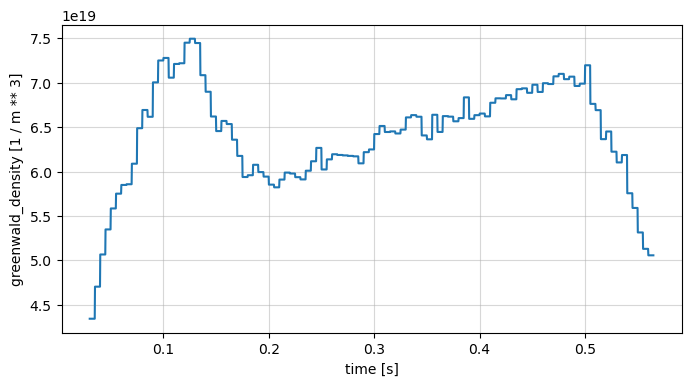

<Figure size 640x480 with 0 Axes>

In [26]:
if True:
    
    # Select target signal from available signals
    target_signal = available_signals[0]
    print(f"Signal '{target_signal}' from source '{target_source}''.")
    
    # Plot signal
    plotting_manager.plot_1d_profiles(
        profiles=source_profiles[target_signal],
        fig_size=[8, 4]
    )


### Plot group of 1D profiles

1d profiles for source 'summary'.


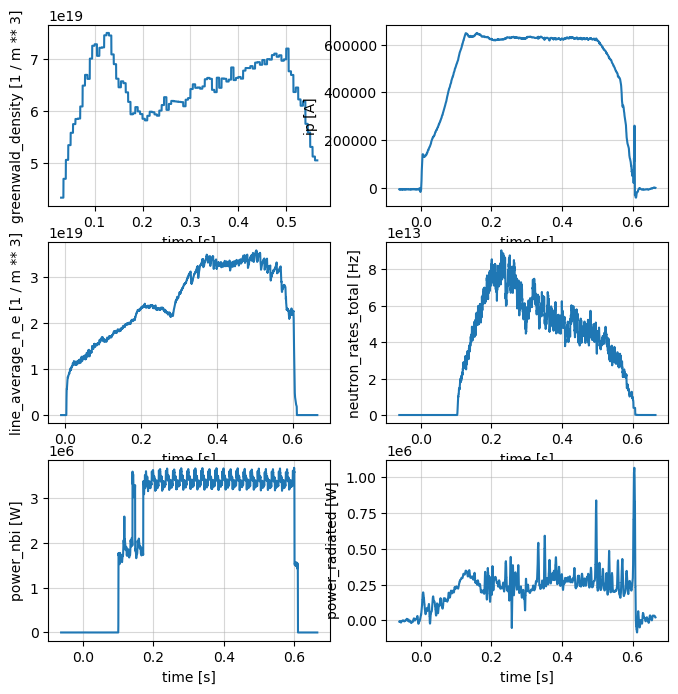

<Figure size 640x480 with 0 Axes>

In [27]:
if True:
    print(f"1d profiles for source '{target_source}'.")
    plotting_manager.plot_1d_profiles(
        profiles=source_profiles,
        fig_size=[8, 8]
    )

### Plot target signal from store

C:\Users\RODRIGOORDONEZ-HURTA\Documents\GitHub\IBM\Fusion related\fairmast-data-preprocessing\notebooks\../scripts\MAST_tools\plotting_utils.py:102: UserWarning: WARNING: This method misbehaves if not run in a notebook with `%matplotlib notebook` header.
  warnings.warn(


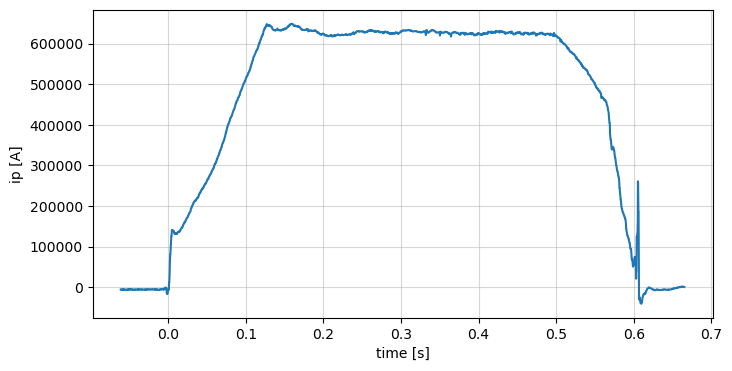

<Figure size 640x480 with 0 Axes>

In [28]:
if True:
    
    source_signal_name = "magnetics-ip"
    
    source_name, signal_name = source_signal_name.split("-")
    plotting_manager.plot_signal(
        data_origin=group_from_shot_info.store,
        source_name=source_name,
        signal_name=signal_name,
        fig_size=[8, 4]
    )

### Plot target signal from shot info

C:\Users\RODRIGOORDONEZ-HURTA\Documents\GitHub\IBM\Fusion related\fairmast-data-preprocessing\notebooks\../scripts\MAST_tools\plotting_utils.py:102: UserWarning: WARNING: This method misbehaves if not run in a notebook with `%matplotlib notebook` header.
  warnings.warn(


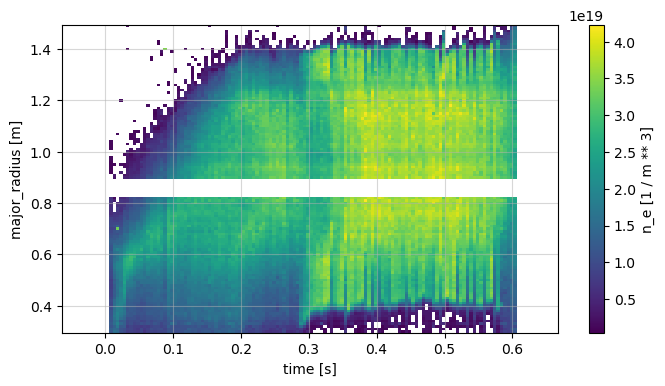

<Figure size 640x480 with 0 Axes>

In [29]:
if True:
    
    source_signal_name = "thomson_scattering-n_e"
    # source_signal_name = "magnetics-ip"
    
    source_name, signal_name = source_signal_name.split("-")
    plotting_manager.plot_signal(
        data_origin={"shot_id": TARGET_SHOT_ID, "local": LOCAL_MODE},
        source_name=source_name,
        signal_name=signal_name,
        fig_size=[8, 4]
    )

### Plot entire signal group from store

In [33]:
if False:  # Heavy for remote mode
    
    # source_name = "magnetics"
    source_name = "thomson_scattering"
    
    plotting_manager.plot_group(
        data_origin=group_from_shot_info.store,
        source_name=source_name,
#         fig_size=[8, 12]
    )

### Plot signal group from shot info

In [35]:
if False:  # Heavy for remote mode
    
    # source_name = "magnetics"
    source_name = "thomson_scattering"
    
    plotting_manager.plot_group(
        data_origin={"shot_id": TARGET_SHOT_ID,"local": LOCAL_MODE},
        source_name=source_name,
#         fig_size=[8, 4]
    )

### Plot specific groups

In [37]:
if True:
    # plotting_manager.plot_plasma_current(data_origin=group_from_shot_info.store)  # -> 1 signal
    # plotting_manager.plot_power_nbi(data_origin=group_from_shot_info.store)  # -> 1 signals
    
    # plotting_manager.plot_charge_exchange(data_origin=group_from_shot_info.store)  # -> 2 signals, heavy for remote
    # plotting_manager.plot_thomson_scattering(data_origin=group_from_shot_info.store)  # -> 2 signals, heavy for remote
    # plotting_manager.plot_spectrometer(data_origin=group_from_shot_info.store)  # -> 3 signals, heavy for remote
    # plotting_manager.plot_magnetics(data_origin=group_from_shot_info.store)  # -> 11 signals, heavy for remote

    pass

---
# MAST_Dataset utilities

## Settings for tests

In [38]:
source_signal_list = [("thomson_scattering", "n_e"), ("magnetics", "flux_loop_flux")]
signal_transform_map = None
shot_transform = None
store_manager_settings = STORE_MANAGER_SETTINGS


## Create MastDataset instance

In [39]:
test_dataset = MastDataset(
    local=LOCAL_MODE,
    shots_list=[30421, 30471],  # [30421, 30471], [TARGET_SHOT_ID]
    source_signal_list=source_signal_list,
    signal_level_transform_map=signal_transform_map,
    shot_level_transform=shot_transform,
    store_manager_settings=STORE_MANAGER_SETTINGS
)

test_dataset


## Check dataset attributes

In [40]:
print(f"test_dataset.shots_list: {test_dataset.shots_list}")
print(f"test_dataset.source_signal_list: {test_dataset.source_signal_list}")

test_dataset.shots_list: [30421, 30471]
test_dataset.source_signal_list: [('thomson_scattering', 'n_e'), ('magnetics', 'flux_loop_flux')]


## Iterate over the created dataset

In [41]:
if True:
    print(test_dataset.__getitem__(1))

{'thomson_scattering-n_e': {'time': None, 'values': None}, 'magnetics-flux_loop_flux': {'time': array([-0.05920029, -0.05900029, -0.05880029, ...,  0.26119971,
        0.26139971,  0.26159971], shape=(1605,)), 'values': array([[ 1.44667685e-01,  1.45430237e-01,  1.46223292e-01, ...,
        -1.78928934e-02, -1.73438452e-02, -1.70083065e-02],
       [ 4.87686120e-05,  4.87991165e-05,  1.10603636e-04, ...,
        -8.76837075e-05,  3.58948309e-05, -1.18509714e-04],
       [ 1.47106200e-01,  1.47924945e-01,  1.48775175e-01, ...,
        -1.81967355e-02, -1.76929031e-02, -1.73465274e-02],
       ...,
       [ 7.69070387e-02,  7.73936436e-02,  7.78802484e-02, ...,
        -2.00925082e-01, -1.99100330e-01, -1.97397247e-01],
       [ 6.46060780e-02,  6.49741441e-02,  6.53421879e-02, ...,
        -2.36410052e-01, -2.34692559e-01, -2.32852370e-01],
       [ 8.01461115e-02,  8.05178434e-02,  8.10134560e-02, ...,
        -1.63235322e-01, -1.61624655e-01, -1.59890085e-01]],
      shape=(15, 1605))

---